In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
folders = os.listdir('/content/drive/MyDrive/dataset')
print(folders)

['dyed-lifted-polyps', 'dyed-resection-margins', 'normal-pylorus', 'polyps', 'esophagitis', 'normal-cecum', 'normal-z-line', 'ulcerative-colitis']


Image count per class:
dyed-lifted-polyps: 1001
dyed-resection-margins: 1000
normal-pylorus: 1000
polyps: 1007
esophagitis: 1000
normal-cecum: 1000
normal-z-line: 1000
ulcerative-colitis: 1000


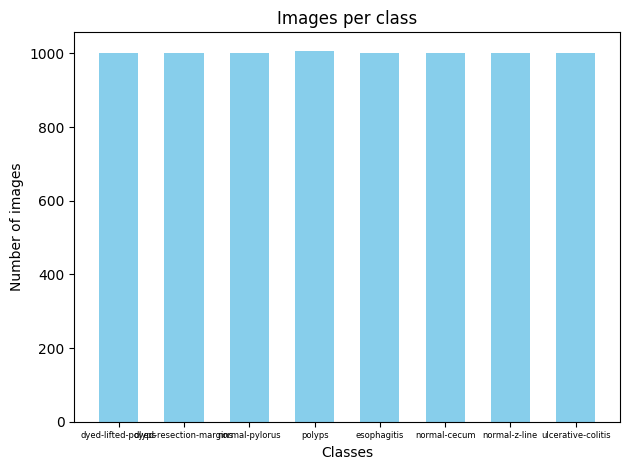

Dataset is relatively balanced ✅


In [4]:
import os
import matplotlib.pyplot as plt
import numpy as np

# مسار الداتا سيت
dataset_path = '/content/drive/MyDrive/dataset'  # غيريه للمسار بتاعك

# جلب أسماء الفئات
classes = os.listdir(dataset_path)
image_count = {}

# عد الصور في كل كلاس
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
    image_count[cls] = count

# عرض النتيجة
print("Image count per class:")
for cls, count in image_count.items():
    print(f"{cls}: {count}")

# إعداد البار شارت
classes = list(image_count.keys())
counts = list(image_count.values())

x = np.arange(len(classes)) * 2  # زيادة المسافة بين الأعمدة
bar_width = 1.2  # عرض البار

plt.bar(x, counts, width=bar_width, color='skyblue')
plt.xlabel("Classes")
plt.ylabel("Number of images")
plt.title("Images per class")
plt.xticks(x, classes, fontsize=6)  # تصغير النص
plt.tight_layout()
plt.show()

# التحقق من التوازن
counts_list = list(image_count.values())
if max(counts_list) - min(counts_list) <= 0.1 * max(counts_list):
    print("Dataset is relatively balanced ✅")
else:
    print("Dataset is imbalanced ⚠️")


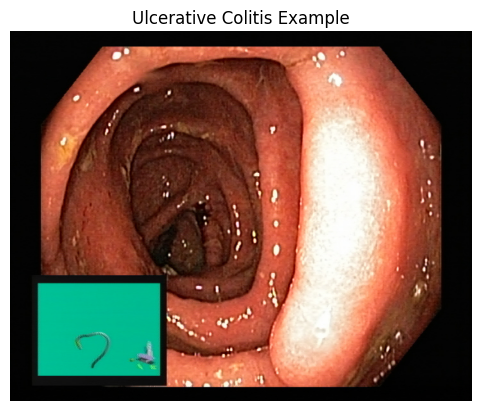

In [6]:
#يطبع صورة من كلاس عشان نتاكد انه وصل للداتا
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ناخد أول صورة من فولدر ulcerative-colitis
img_path = os.path.join('/content/drive/MyDrive/dataset', 'ulcerative-colitis', os.listdir(os.path.join('/content/drive/MyDrive/dataset', 'ulcerative-colitis'))[0])

# نقرأها
img = mpimg.imread(img_path)

# نعرضها
plt.imshow(img)
plt.title("Ulcerative Colitis Example")
plt.axis('off')
plt.show()

In [7]:
import os
import shutil
from sklearn.model_selection import train_test_split

original_path = '/content/drive/MyDrive/dataset'
split_path    = '/content/drive/MyDrive/dataset_split_RR '

# تنظيف أي تقسيم قديم
shutil.rmtree(split_path, ignore_errors=True)

splits = ['train', 'val', 'test']
for s in splits:
    os.makedirs(os.path.join(split_path, s), exist_ok=True)

for cls in os.listdir(original_path):
    cls_path = os.path.join(original_path, cls)
    if not os.path.isdir(cls_path):
        continue

    # نعدّ الصور بس
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.jpg','.jpeg','.png'))]

    # 80% train
    train_imgs, temp_imgs = train_test_split(
        images, test_size=0.20, random_state=42
    )

    # 10% val – 10% test
    val_imgs, test_imgs = train_test_split(
        temp_imgs, test_size=0.50, random_state=42
    )

    for split_name, split_imgs in zip(splits, [train_imgs, val_imgs, test_imgs]):
        out_dir = os.path.join(split_path, split_name, cls)
        os.makedirs(out_dir, exist_ok=True)

        for img in split_imgs:
            shutil.copy(
                os.path.join(cls_path, img),
                os.path.join(out_dir, img)
            )

print("✅ Dataset split completed: 80% Train / 10% Val / 10% Test")


✅ Dataset split completed: 80% Train / 10% Val / 10% Test


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet_v2 import preprocess_input

img_size = (224,224)
batch_size = 32
base_path = '/content/drive/MyDrive/dataset_split_RR '

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    f'{base_path}/train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    f'{base_path}/val',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    f'{base_path}/test',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 6405 images belonging to 8 classes.
Found 801 images belonging to 8 classes.
Found 802 images belonging to 8 classes.


In [14]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

base_model = ResNet50V2(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last 30 layers (except BatchNorm)
for layer in base_model.layers[-30:]:
    if not isinstance(layer, BatchNormalization):
        layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

num_classes = train_generator.num_classes
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 24,099,592 (91.93 MB)

 Trainable params: 14,956,808 (57.06 MB)

 Non-trainable params: 9,142,784 (34.88 MB)

In [15]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint(
        '/content/drive/MyDrive/best_resnet_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        verbose=1
    )
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks
)


Epoch 1/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 795ms/step - accuracy: 0.6147 - loss: 1.1207
Epoch 1: val_accuracy improved from -inf to 0.83521, saving model to /content/drive/MyDrive/best_resnet_model.h5


201/201 ━━━━━━━━━━━━━━━━━━━━ 198s 898ms/step - accuracy: 0.6153 - loss: 1.1187 - val_accuracy: 0.8352 - val_loss: 0.4801 - learning_rate: 1.0000e-04
Epoch 2/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.8529 - loss: 0.4136
Epoch 2: val_accuracy improved from 0.83521 to 0.84270, saving model to /content/drive/MyDrive/best_resnet_model.h5


201/201 ━━━━━━━━━━━━━━━━━━━━ 168s 837ms/step - accuracy: 0.8530 - loss: 0.4135 - val_accuracy: 0.8427 - val_loss: 0.4355 - learning_rate: 1.0000e-04
Epoch 3/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 761ms/step - accuracy: 0.8859 - loss: 0.2966
Epoch 3: val_accuracy did not improve from 0.84270
201/201 ━━━━━━━━━━━━━━━━━━━━ 164s 813ms/step - accuracy: 0.8859 - loss: 0.2967 - val_accuracy: 0.8302 - val_loss: 0.3809 - learning_rate: 1.0000e-04
Epoch 4/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 746ms/step - accuracy: 0.8978 - loss: 0.2581
Epoch 4: val_accuracy improved from 0.84270 to 0.85518, saving model to /content/drive/MyDrive/best_resnet_model.h5


201/201 ━━━━━━━━━━━━━━━━━━━━ 169s 841ms/step - accuracy: 0.8978 - loss: 0.2581 - val_accuracy: 0.8552 - val_loss: 0.3312 - learning_rate: 1.0000e-04
Epoch 5/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.9128 - loss: 0.2188
Epoch 5: val_accuracy did not improve from 0.85518
201/201 ━━━━━━━━━━━━━━━━━━━━ 209s 876ms/step - accuracy: 0.9128 - loss: 0.2189 - val_accuracy: 0.8352 - val_loss: 0.3918 - learning_rate: 1.0000e-04
Epoch 6/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - accuracy: 0.9184 - loss: 0.2048
Epoch 6: val_accuracy improved from 0.85518 to 0.86142, saving model to /content/drive/MyDrive/best_resnet_model.h5


201/201 ━━━━━━━━━━━━━━━━━━━━ 168s 838ms/step - accuracy: 0.9184 - loss: 0.2047 - val_accuracy: 0.8614 - val_loss: 0.3769 - learning_rate: 1.0000e-04
Epoch 7/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 752ms/step - accuracy: 0.9207 - loss: 0.1884
Epoch 7: val_accuracy improved from 0.86142 to 0.88889, saving model to /content/drive/MyDrive/best_resnet_model.h5


201/201 ━━━━━━━━━━━━━━━━━━━━ 203s 845ms/step - accuracy: 0.9207 - loss: 0.1884 - val_accuracy: 0.8889 - val_loss: 0.3243 - learning_rate: 1.0000e-04
Epoch 8/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.9329 - loss: 0.1698
Epoch 8: val_accuracy did not improve from 0.88889
201/201 ━━━━━━━━━━━━━━━━━━━━ 169s 840ms/step - accuracy: 0.9329 - loss: 0.1699 - val_accuracy: 0.8714 - val_loss: 0.4276 - learning_rate: 1.0000e-04
Epoch 9/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.9402 - loss: 0.1457
Epoch 9: val_accuracy improved from 0.88889 to 0.89513, saving model to /content/drive/MyDrive/best_resnet_model.h5


201/201 ━━━━━━━━━━━━━━━━━━━━ 167s 833ms/step - accuracy: 0.9401 - loss: 0.1457 - val_accuracy: 0.8951 - val_loss: 0.3311 - learning_rate: 1.0000e-04
Epoch 10/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 785ms/step - accuracy: 0.9463 - loss: 0.1348
Epoch 10: val_accuracy did not improve from 0.89513

Epoch 10: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
201/201 ━━━━━━━━━━━━━━━━━━━━ 169s 839ms/step - accuracy: 0.9463 - loss: 0.1348 - val_accuracy: 0.8864 - val_loss: 0.3272 - learning_rate: 1.0000e-04
Epoch 11/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - accuracy: 0.9620 - loss: 0.0972
Epoch 11: val_accuracy did not improve from 0.89513
201/201 ━━━━━━━━━━━━━━━━━━━━ 164s 815ms/step - accuracy: 0.9620 - loss: 0.0972 - val_accuracy: 0.8926 - val_loss: 0.3062 - learning_rate: 2.0000e-05
Epoch 12/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 757ms/step - accuracy: 0.9701 - loss: 0.0749
Epoch 12: val_accuracy did not improve from 0.89513
201/201 ━━━━━━━━━━━━━━━━━━━━ 163s 812ms/step - accu

201/201 ━━━━━━━━━━━━━━━━━━━━ 171s 851ms/step - accuracy: 0.9761 - loss: 0.0597 - val_accuracy: 0.8964 - val_loss: 0.3944 - learning_rate: 2.0000e-05
Epoch 14/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 780ms/step - accuracy: 0.9818 - loss: 0.0492
Epoch 14: val_accuracy improved from 0.89638 to 0.90137, saving model to /content/drive/MyDrive/best_resnet_model.h5



Epoch 14: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.
201/201 ━━━━━━━━━━━━━━━━━━━━ 175s 870ms/step - accuracy: 0.9818 - loss: 0.0492 - val_accuracy: 0.9014 - val_loss: 0.4075 - learning_rate: 2.0000e-05
Epoch 15/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.9809 - loss: 0.0490
Epoch 15: val_accuracy did not improve from 0.90137
201/201 ━━━━━━━━━━━━━━━━━━━━ 167s 830ms/step - accuracy: 0.9810 - loss: 0.0490 - val_accuracy: 0.8976 - val_loss: 0.3577 - learning_rate: 4.0000e-06


In [16]:
final_train_acc = history.history['accuracy'][-1]

final_val_acc = history.history['val_accuracy'][-1]

print(f"🔹 Final Training Accuracy: {final_train_acc:.4f}")
print(f"🔸 Final Validation Accuracy: {final_val_acc:.4f}")

🔹 Final Training Accuracy: 0.9822
🔸 Final Validation Accuracy: 0.8976


/tmp/ipython-input-523748710.py:36: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-523748710.py:36: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


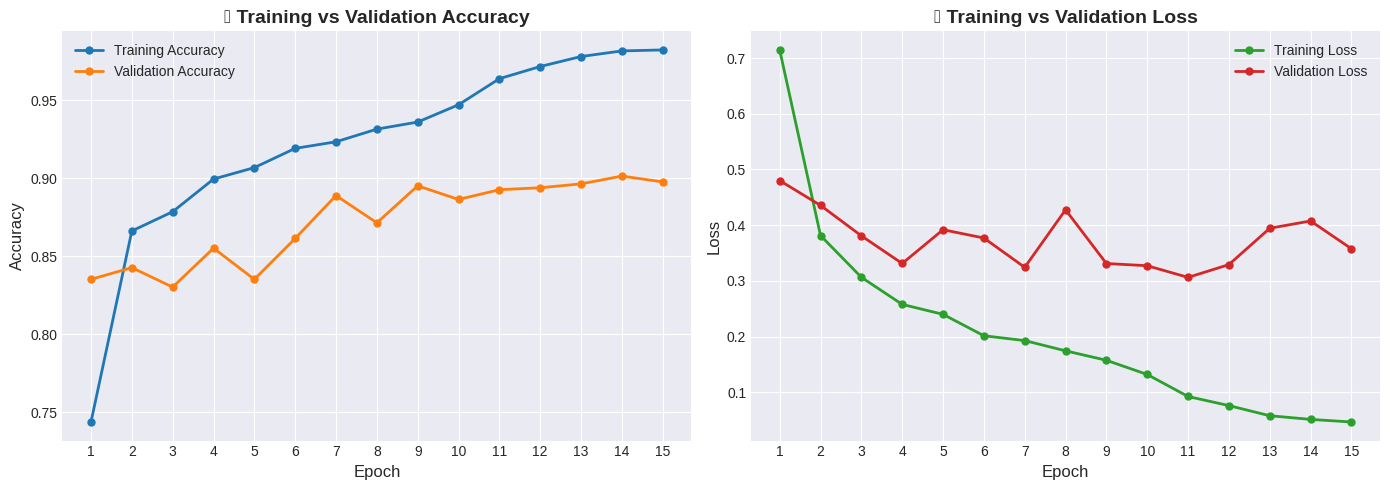

In [17]:
import matplotlib.pyplot as plt

# استخراج القيم من history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(14, 5))

# منحنى الدقة
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Training Accuracy', color='#1f77b4', linewidth=2, markersize=5)
plt.plot(epochs_range, val_acc, 'o-', label='Validation Accuracy', color='#ff7f0e', linewidth=2, markersize=5)
plt.title('📈 Training vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(epochs_range)
plt.legend()
plt.grid(True)

# منحنى الخسارة
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Training Loss', color='#2ca02c', linewidth=2, markersize=5)
plt.plot(epochs_range, val_loss, 'o-', label='Validation Loss', color='#d62728', linewidth=2, markersize=5)
plt.title('📉 Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs_range)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
test_loss, test_acc = model.evaluate(test_generator)
print(f" Test Accuracy: {test_acc*100:.2f}%")


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


26/26 ━━━━━━━━━━━━━━━━━━━━ 16s 605ms/step - accuracy: 0.9178 - loss: 0.3206
🔥 Test Accuracy: 92.52%


In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# التوقعات
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)

# Classification Report
cr = classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys())
print("Classification Report:\n", cr)

26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 559ms/step
Confusion Matrix:
 [[ 94   5   0   0   0   0   1   1]
 [  8  92   0   0   0   0   0   0]
 [  0   0  85   0   1  14   0   0]
 [  0   0   0  97   0   0   2   1]
 [  0   0   0   0 100   0   0   0]
 [  0   0  17   0   1  82   0   0]
 [  2   0   0   1   0   0  97   1]
 [  0   0   0   1   1   0   3  95]]
Classification Report:
                         precision    recall  f1-score   support

    dyed-lifted-polyps       0.90      0.93      0.92       101
dyed-resection-margins       0.95      0.92      0.93       100
           esophagitis       0.83      0.85      0.84       100
          normal-cecum       0.98      0.97      0.97       100
        normal-pylorus       0.97      1.00      0.99       100
         normal-z-line       0.85      0.82      0.84       100
                polyps       0.94      0.96      0.95       101
    ulcerative-colitis       0.97      0.95      0.96       100

              accuracy                           0.93   

26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 431ms/step


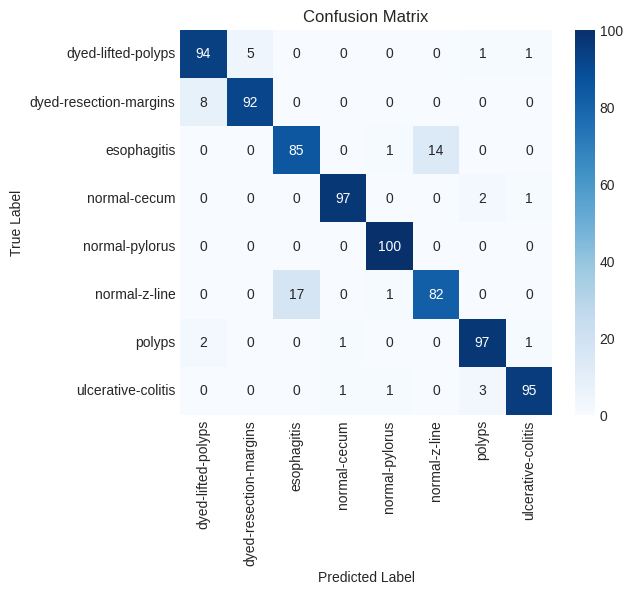

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np


y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())


cm = confusion_matrix(y_true, y_pred_classes)


plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

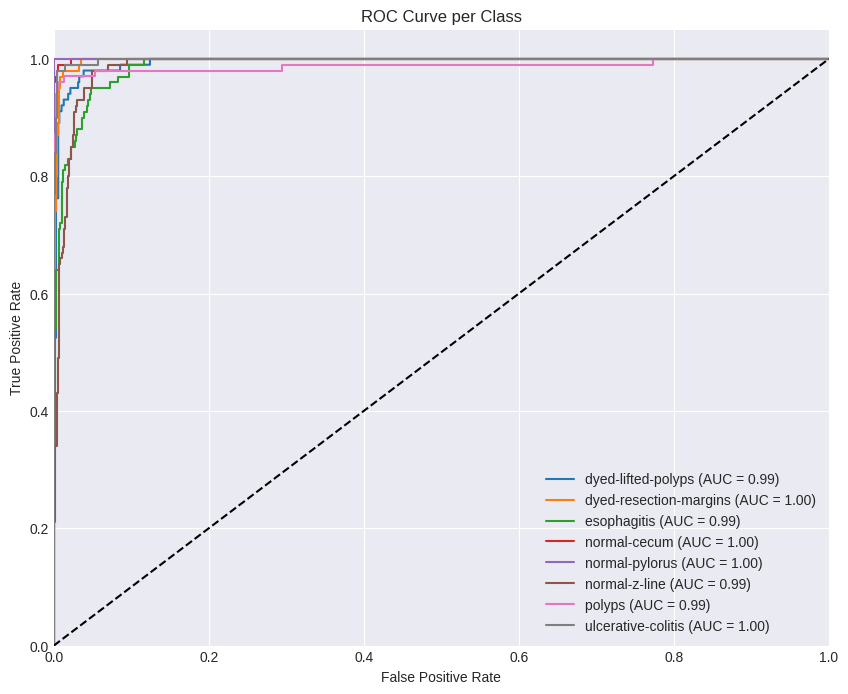

In [21]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get class names from the test_generator
class_names = list(test_generator.class_indices.keys())

# One-hot encoding للـ labels
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = y_true_bin.shape[1]

plt.figure(figsize=(10,8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_pred[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')  # خط الRandom
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class')
plt.legend(loc='lower right')
plt.show()

In [22]:
import cv2
import numpy as np
from tensorflow.keras.applications.resnet_v2 import preprocess_input


def load_and_preprocess_image(img_path, target_size=(224,224)):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("الصورة مش موجودة أو المسار غلط")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = np.expand_dims(img, axis=0)  # إضافة batch dimension
    img = preprocess_input(img)  # لازم زي ما عملنا في الـ train
    return img

img_path = '/content/drive/MyDrive/dataset_split_RR /test/polyps/04e4ce01-407a-4367-bfef-27980a0b1d7d.jpg'
img = load_and_preprocess_image(img_path)


pred_prob = model.predict(img)  # probability لكل كلاس
pred_class = np.argmax(pred_prob, axis=1)[0]  # index للكلاس المتوقع

class_labels = list(train_generator.class_indices.keys())  # أسماء الكلاسات
print(f"الصورة تنتمي لكلاس: {class_labels[pred_class]}")
print(f"احتمالية كل كلاس: {pred_prob}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
الصورة تنتمي لكلاس: polyps
احتمالية كل كلاس: [[1.1792921e-09 5.1390957e-11 8.4528158e-13 1.6956204e-09 9.3320377e-12
  1.0443182e-10 1.0000000e+00 3.2329108e-09]]
